# **Agent Bot**

## **Simple AgentBot with Ollama**

In [2]:
from typing import TypedDict, List
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv 
from langchain_ollama import ChatOllama
import os


load_dotenv()

api_key = os.getenv("OPENAI_API_KEY")
base_url = os.getenv("BASE_URL")

class AgentState(TypedDict):
    messages: List[HumanMessage]

#llm = ChatOpenAI(model="gpt-4o", api_key=api_key, base_url=base_url, temperature=0.7)
ollama = ChatOllama(model="qwen3.8:latest", temperature=0.7)


def process(state: AgentState) -> AgentState:
    response = ollama.invoke(state["messages"])
    print(f"\nAI: {response.content}")
    return state

graph = StateGraph(AgentState)
graph.add_node("process", process)
graph.add_edge(START, "process")
graph.add_edge("process", END) 
agent = graph.compile()

user_input = input("Enter: ")
while user_input != "exit":
    agent.invoke({"messages": [HumanMessage(content=user_input)]})
    user_input = input("Enter: ")



AI: I'm **Qwen** (also known as Tongyi Qianwen), a large language model developed by Alibaba Group's Tongyi Lab. How can I help you today?


## **AgentBot with memory and log file**

In [5]:
from typing import TypedDict, List, Union
from langchain_core.messages import HumanMessage, AIMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

class AgentState(TypedDict):
    messages: List[Union[HumanMessage, AIMessage]]

def process(state: AgentState) -> AgentState:
    """This node will solve the request you input"""
    response = ollama.invoke(state["messages"])

    state["messages"].append(AIMessage(content=response.content)) 
    print(f"\nAI: {response.content}")
    print("CURRENT STATE: ", state["messages"])

    return state

graph = StateGraph(AgentState)
graph.add_node("process", process)
graph.add_edge(START, "process")
graph.add_edge("process", END) 
agent = graph.compile()


conversation_history = []

user_input = input("Enter: ")
while user_input != "exit":
    conversation_history.append(HumanMessage(content=user_input))
    result = agent.invoke({"messages": conversation_history})
    conversation_history = result["messages"]
    user_input = input("Enter: ")


with open("logging.txt", "w", encoding="utf-8") as file:
    file.write("Your Conversation Log:\n")
    
    for message in conversation_history:
        if isinstance(message, HumanMessage):
            file.write(f"You: {message.content}\n")
        elif isinstance(message, AIMessage):
            file.write(f"AI: {message.content}\n\n")
    file.write("End of Conversation")

print("Conversation saved to logging.txt")


AI: Hi Meisam! Nice to meet you. 😊

I'm **Qwen** (Tongyi Qianwen), a large language model developed by Alibaba Group's Tongyi Lab. I'm here to help you with all sorts of things — answering questions, brainstorming ideas, writing, coding, analyzing problems, translating, having a conversation, or really anything else that's on your mind.

So, what can I help you with today?
CURRENT STATE:  [HumanMessage(content='I am Meisam 35 years old. Who are you?', additional_kwargs={}, response_metadata={}), AIMessage(content="Hi Meisam! Nice to meet you. 😊\n\nI'm **Qwen** (Tongyi Qianwen), a large language model developed by Alibaba Group's Tongyi Lab. I'm here to help you with all sorts of things — answering questions, brainstorming ideas, writing, coding, analyzing problems, translating, having a conversation, or really anything else that's on your mind.\n\nSo, what can I help you with today?", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]

AI: # LangGraph



## **ReAct Agent**

In [8]:
from typing import Annotated, Sequence, TypedDict
from dotenv import load_dotenv  
from langchain_core.messages import BaseMessage # The foundational class for all message types in LangGraph
from langchain_core.messages import ToolMessage # Passes data back to LLM after it calls a tool such as the content and the tool_call_id
from langchain_core.messages import SystemMessage # Message for providing instructions to the LLM
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode


load_dotenv()

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]


@tool
def add(a: int, b:int):
    """This is an addition function that adds 2 numbers together"""

    return a + b 

@tool
def subtract(a: int, b: int):
    """Subtraction function"""
    return a - b

@tool
def multiply(a: int, b: int):
    """Multiplication function"""
    return a * b

tools = [add, subtract, multiply]

#model = ChatOpenAI(model = "gpt-4o").bind_tools(tools)
model = ollama.bind_tools(tools)


def model_call(state:AgentState) -> AgentState:
    system_prompt = SystemMessage(content=
        "You are my AI assistant, please answer my query to the best of your ability."
    )
    response = model.invoke([system_prompt] + state["messages"])
    return {"messages": [response]}


def should_continue(state: AgentState):     # Routing Function (Reason → Act → Observe → Reason...)
    messages = state["messages"]
    last_message = messages[-1]
    if not last_message.tool_calls: 
        return "end"
    else:
        return "continue"
    

graph = StateGraph(AgentState)
graph.add_node("our_agent", model_call)

tool_node = ToolNode(tools=tools)
graph.add_node("tools", tool_node)

graph.set_entry_point("our_agent")

graph.add_conditional_edges(
    "our_agent",
    should_continue,
    {
        "continue": "tools",
        "end": END,
    },
)

graph.add_edge("tools", "our_agent")

app = graph.compile()

def print_stream(stream):
    for s in stream:
        message = s["messages"][-1]
        if isinstance(message, tuple):      # tuple messages
            #print(message)
            pass
        else:
            message.pretty_print()          # regular messages

inputs = {"messages": [("user", "Add 40 + 12 and then multiply the result by 6. Also tell me a joke please.")]}
print_stream(app.stream(inputs, stream_mode="values"))


================================ Human Message =================================

Add 40 + 12 and then multiply the result by 6. Also tell me a joke please.
================================== Ai Message ==================================
Tool Calls:
  add (ba932549-dc9b-4c85-a696-c47459e055ae)
 Call ID: ba932549-dc9b-4c85-a696-c47459e055ae
  Args:
    a: 40
    b: 12
================================= Tool Message =================================
Name: add

52
================================== Ai Message ==================================
Tool Calls:
  multiply (fd9c50f4-7a8e-4857-a3fd-8d2fc92fad14)
 Call ID: fd9c50f4-7a8e-4857-a3fd-8d2fc92fad14
  Args:
    a: 52
    b: 6
================================= Tool Message =================================
Name: multiply

312
================================== Ai Message ==================================

Here's your math:

1. **40 + 12 = 52**
2. **52 × 6 = 312**

✅ Final answer: **312**

---

And here's a joke for you:

> Why don't scien

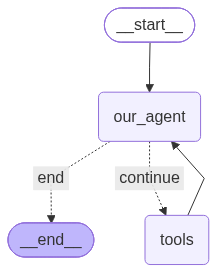

In [7]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Visualization is optional; graph execution still works.")
    print(type(e).__name__, e)

## **Drafter as writing assistant**

In [ ]:
from typing import Annotated, Sequence, TypedDict
from dotenv import load_dotenv  
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode

load_dotenv()

# Global variable to store document content across the entire session
document_content = ""

class AgentState(TypedDict):
    # messages field with add_messages reducer - automatically appends new messages
    messages: Annotated[Sequence[BaseMessage], add_messages]


@tool
def update(content: str) -> str:
    """Updates the document with the provided content."""
    # Access the global document content variable
    global document_content
    # Replace the entire document with new content
    document_content = content
    return f"Document has been updated successfully! The current content is:\n{document_content}"


@tool
def save(filename: str) -> str:
    """Save the current document to a text file and finish the process.
    
    Args:
        filename: Name for the text file.
    """

    # Access the global document content
    global document_content

    # Add .txt extension if user didn't include it
    if not filename.endswith('.txt'):
        filename = f"{filename}.txt"

    # Try to save the file, catch any errors
    try:
        with open(filename, 'w') as file:
            file.write(document_content)
        # Print confirmation to console
        print(f"\n💾 Document has been saved to: {filename}")
        return f"Document has been saved successfully to '{filename}'."
    
    except Exception as e:
        return f"Error saving document: {str(e)}"
    

# List of all tools available to the agent
tools = [update, save]

# Initialize GPT-4o model and bind tools so it knows when to call them
#model = ChatOpenAI(model="gpt-4o").bind_tools(tools)
model = ollama.bind_tools(tools)

def our_agent(state: AgentState) -> AgentState:
    # Create system prompt with instructions and current document content
    system_prompt = SystemMessage(content=f"""
    You are Drafter, a helpful writing assistant. You are going to help the user update and modify documents.
    
    - If the user wants to update or modify content, use the 'update' tool with the complete updated content.
    - If the user wants to save and finish, you need to use the 'save' tool.
    - Make sure to always show the current document state after modifications.
    
    The current document content is:{document_content}
    """)

    # If no messages yet (first turn), auto-prompt the user
    if not state["messages"]:
        user_input = "I'm ready to help you update a document. What would you like to create?"
        user_message = HumanMessage(content=user_input)

    # Otherwise, get user input from console
    else:
        user_input = input("\nWhat would you like to do with the document? ")
        print(f"\n👤 USER: {user_input}")
        user_message = HumanMessage(content=user_input)

    # Combine system prompt, conversation history, and new user message
    all_messages = [system_prompt] + list(state["messages"]) + [user_message]

    # Invoke the LLM with all messages
    response = model.invoke(all_messages)

    # Print the AI's response
    print(f"\n🤖 AI: {response.content}")
    # If the AI called tools, show which ones
    if hasattr(response, "tool_calls") and response.tool_calls:
        print(f"🔧 USING TOOLS: {[tc['name'] for tc in response.tool_calls]}")

    # Return updated state with new user message and AI response appended
    return {"messages": list(state["messages"]) + [user_message, response]}


def should_continue(state: AgentState) -> str:
    """Determine if we should continue or end the conversation."""

    messages = state["messages"]
    
    # If no messages, continue (shouldn't happen)
    if not messages:
        return "continue"
    
    # Look through messages from newest to oldest
    for message in reversed(messages):
        # Check if this is a ToolMessage from the save tool
        # The save tool returns "Document has been saved successfully"
        if (isinstance(message, ToolMessage) and 
            "saved" in message.content.lower() and
            "document" in message.content.lower()):
            # If save was used, end the conversation
            return "end"
        
    # Otherwise, continue the conversation
    return "continue"

def print_messages(messages):
    """Function I made to print the messages in a more readable format"""
    if not messages:
        return
    
    # Only show the last 3 messages to keep output clean
    for message in messages[-3:]:
        # If it's a tool result, show it with an emoji
        if isinstance(message, ToolMessage):
            print(f"\n🛠️ TOOL RESULT: {message.content}")


# Create a new graph with AgentState as the state schema
graph = StateGraph(AgentState)

# Add the agent node (calls LLM)
graph.add_node("agent", our_agent)
# Add the tools node (executes tools)
graph.add_node("tools", ToolNode(tools))

# The graph starts at the agent node
graph.set_entry_point("agent")

# After agent, always go to tools (to execute any tool calls)
graph.add_edge("agent", "tools")

# After tools, check if we should continue or end
graph.add_conditional_edges(
    "tools",
    should_continue,  # Function that decides next step
    {
        "continue": "agent",  # If continue, go back to agent (loop)
        "end": END,  # If end, stop execution
    },
)

# Compile the graph into a runnable application
app = graph.compile()


"""Main function to run the document agent"""
print("\n ===== DRAFTER =====")

# Initialize empty state
state = {"messages": []}

# Stream the graph execution step by step
for step in app.stream(state, stream_mode="values"):
    # Print messages at each step
    if "messages" in step:
        print_messages(step["messages"])

print("\n ===== DRAFTER FINISHED =====")


## **Simple RAG agent**

### **Create vector database using Chromadb**

In [12]:
from dotenv import load_dotenv
import os
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, ToolMessage
from operator import add as add_messages
from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_core.tools import tool
from langchain_huggingface import HuggingFaceEmbeddings

load_dotenv()

#llm = ChatOpenAI(model="gpt-4o", temperature = 0) # Minimize hallucination - temperature = 0 makes the model output more deterministic 
ollama = ChatOllama(model="qwen3.8:latest", temperature=0)

# Our Embedding Model - has to also be compatible with the LLM
#embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",  # Popular small model
    model_kwargs={'device': 'cuda'},  # Use 'cuda' if you have GPU
    encode_kwargs={'normalize_embeddings': True}
)

pdf_path = "Stock_Market_Performance_2024.pdf"

# Safety measure I have put for debugging purposes :)
if not os.path.exists(pdf_path):
    raise FileNotFoundError(f"PDF file not found: {pdf_path}")

pdf_loader = PyPDFLoader(pdf_path) # This loads the PDF

# Checks if the PDF is there
try:
    pages = pdf_loader.load()
    print(f"PDF has been loaded and has {len(pages)} pages")
except Exception as e:
    print(f"Error loading PDF: {e}")
    raise

# Chunking Process
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)


pages_split = text_splitter.split_documents(pages) # We now apply this to our pages

persist_directory = r"C:\Users\meisa\Desktop\Code\ML\Agent_AI\LangGraph-Course-freeCodeCamp-main\Agents"
collection_name = "stock_market_hf"

# If our collection does not exist in the directory, we create using the os command
if not os.path.exists(persist_directory):
    os.makedirs(persist_directory)


try:
    # Here, we actually create the chroma database using our embeddigns model
    vectorstore = Chroma.from_documents(
        documents=pages_split,
        embedding=embeddings,
        persist_directory=persist_directory,
        collection_name=collection_name
    )
    print(f"Created ChromaDB vector store!")
    
except Exception as e:
    print(f"Error setting up ChromaDB: {str(e)}")
    raise


# Now we create our retriever 
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 5} # K is the amount of chunks to return
)

PDF has been loaded and has 9 pages
Created ChromaDB vector store!


### **Test vector store**

In [23]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# Load the existing vector store
print("📂 Loading ChromaDB vector store...")
try:
    vectorstore = Chroma(
        persist_directory=persist_directory,
        embedding_function=embeddings,
        collection_name=collection_name
    )
    print(f"✅ Vector store loaded successfully!")
    
    # Get collection info
    collection = vectorstore._collection
    count = collection.count()
    results = collection.get()
    print(f"📊 Total documents in collection: {count}")
    print(f"📊 Documents retrieved: {len(results['documents'])}")
    
except Exception as e:
    print(f"❌ Error loading vector store: {e}")
    exit(1)

# ============================================
# 2. VIEW ALL DOCUMENTS IN THE VECTOR STORE
# ============================================

def view_all_documents(vectorstore, limit=10):
    """View all documents stored in the vector store"""
    print("\n" + "=" * 60)
    print("📄 ALL DOCUMENTS IN VECTOR STORE")
    print("=" * 60)
    
    # Get all documents from the collection
    collection = vectorstore._collection
    results = collection.get()
    
    if not results['documents']:
        print("No documents found in the collection.")
        return
    
    print(f"Total documents: {len(results['documents'])}\n")
    
    for i, (doc, metadata, id) in enumerate(zip(
        results['documents'][:limit], 
        results['metadatas'][:limit], 
        results['ids'][:limit]
    )):
        print(f"\n📌 Document {i+1} (ID: {id})")
        print(f"   Metadata: {metadata}")
        print(f"   Content preview: {doc[:300]}..." if len(doc) > 300 else f"   Content: {doc}")
        print("-" * 40)

# ============================================
# 3. TEST SIMILARITY SEARCH
# ============================================

def test_similarity_search(vectorstore, query, k=5):
    """Test similarity search with a query"""
    print("\n" + "=" * 60)
    print(f"🔍 SIMILARITY SEARCH: '{query}'")
    print("=" * 60)
    
    results = vectorstore.similarity_search_with_score(query, k=k)
    
    if not results:
        print("No results found.")
        return
    
    print(f"\nFound {len(results)} results:\n")
    
    for i, (doc, score) in enumerate(results):
        print(f"📌 Result {i+1} (Score: {score:.4f})")
        print(f"   Content preview: {doc.page_content[:300]}..." if len(doc.page_content) > 300 else f"   Content: {doc.page_content}")
        if doc.metadata:
            print(f"   Metadata: {doc.metadata}")
        print("-" * 40)

# ============================================
# 4. GET SPECIFIC DOCUMENT BY ID
# ============================================

def get_document_by_id(vectorstore, doc_id):
    """Retrieve a specific document by its ID"""
    print("\n" + "=" * 60)
    print(f"🔎 RETRIEVING DOCUMENT: {doc_id}")
    print("=" * 60)
    
    collection = vectorstore._collection
    result = collection.get(ids=[doc_id])
    
    if not result['documents']:
        print(f"Document with ID '{doc_id}' not found.")
        return
    
    print(f"\nDocument found:")
    print(f"   ID: {result['ids'][0]}")
    print(f"   Metadata: {result['metadatas'][0]}")
    print(f"   Content:\n{result['documents'][0]}")

# ============================================
# 5. TEST TOKEN/TEXT SIMILARITY
# ============================================

def test_text_similarity(embeddings, texts):
    """Test similarity between different texts"""
    print("\n" + "=" * 60)
    print("🔬 TEXT SIMILARITY TESTING")
    print("=" * 60)
    
    # Generate embeddings for all texts
    embeddings_list = embeddings.embed_documents(texts)
    
    print(f"\nTesting similarity between {len(texts)} texts:\n")
    
    # Show each text
    for i, text in enumerate(texts):
        print(f"📝 Text {i+1}: {text[:100]}..." if len(text) > 100 else f"📝 Text {i+1}: {text}")
    
    print("\n" + "-" * 40)
    print("📊 SIMILARITY MATRIX (Cosine Similarity)")
    print("-" * 40)
    
    # Calculate cosine similarity matrix
    similarity_matrix = cosine_similarity(embeddings_list)
    
    # Create a DataFrame for better visualization
    df = pd.DataFrame(
        similarity_matrix,
        columns=[f"Text {i+1}" for i in range(len(texts))],
        index=[f"Text {i+1}" for i in range(len(texts))]
    )
    
    # Round to 4 decimal places for readability
    df = df.round(4)
    print(df)
    
    # Find most similar pairs
    print("\n" + "-" * 40)
    print("🎯 MOST SIMILAR PAIRS")
    print("-" * 40)
    
    for i in range(len(texts)):
        for j in range(i+1, len(texts)):
            similarity = similarity_matrix[i][j]
            print(f"  Text {i+1} ↔ Text {j+1}: {similarity:.4f}")

# ============================================
# 6. COMPARE QUERY WITH DOCUMENTS
# ============================================

def compare_query_with_documents(vectorstore, query, k=3):
    """Compare a query with documents in the vector store"""
    print("\n" + "=" * 60)
    print(f"📊 QUERY VS DOCUMENTS COMPARISON")
    print("=" * 60)
    
    print(f"\n🔍 Query: '{query}'\n")
    
    results = vectorstore.similarity_search_with_score(query, k=k)
    
    print(f"Top {k} most similar documents:\n")
    for i, (doc, score) in enumerate(results):
        print(f"📌 Document {i+1}")
        print(f"   Similarity Score: {score:.4f} (lower = more similar)")
        print(f"   Content preview: {doc.page_content[:200]}..." if len(doc.page_content) > 200 else f"   Content: {doc.page_content}")
        print("-" * 40)

# ============================================
# 7. GET COLLECTION STATISTICS
# ============================================

def get_collection_stats(vectorstore):
    """Get statistics about the vector store collection"""
    print("\n" + "=" * 60)
    print("📊 COLLECTION STATISTICS")
    print("=" * 60)
    
    collection = vectorstore._collection
    
    # Get all documents
    results = collection.get()
    
    print(f"\n📈 Collection Name: {collection_name}")
    print(f"📄 Total Documents: {len(results['documents'])}")
    print(f"📏 Embedding Dimension: {len(embeddings.embed_query('test'))}")
    print(f"📁 Persistence Directory: {persist_directory}")
    
    # Count unique metadata values if they exist
    if results['metadatas']:
        # Check for source metadata
        sources = [m.get('source', 'unknown') for m in results['metadatas'] if m]
        if sources:
            unique_sources = set(sources)
            print(f"\n📚 Sources:")
            for source in unique_sources:
                count = sources.count(source)
                print(f"   - {source}: {count} documents")


# ============================================
# 8. MAIN EXECUTION
# ============================================

if  __name__ == "__main__":
    
    # 1. View all documents
    view_all_documents(vectorstore, limit=1)
    
    # 2. Test similarity search
    test_queries = [
        "What was the stock market performance in 2024?",
        "How did tech stocks perform?",
        "What were the economic factors?"
    ]
    
    for query in test_queries:
        test_similarity_search(vectorstore, query, k=3)
        print("\n" + "=" * 60)
    
    # 3. Test text similarity
    test_texts = [
        "stock market performance in 2024 was strong",
        "technology stocks had significant gains",
        "the economy showed resilience",
        "interest rates affected market conditions",
        "I like to eat pizza and pasta"  # This should be less similar
    ]
    test_text_similarity(embeddings, test_texts)
    
    # 4. Get collection stats
    get_collection_stats(vectorstore)
    
    # 5. Interactive mode
    print("\n" + "=" * 60)
    print("🔍 INTERACTIVE SIMILARITY SEARCH MODE")
    print("=" * 60)
    print("Type 'exit' to quit\n")
    
    while True:
        query = input("\nEnter your query: ").strip()
        if query.lower() in ['exit', 'quit', 'q']:
            break
        if not query:
            continue
        
        compare_query_with_documents(vectorstore, query, k=3)

📂 Loading ChromaDB vector store...
✅ Vector store loaded successfully!
📊 Total documents in collection: 24
📊 Documents retrieved: 24

📄 ALL DOCUMENTS IN VECTOR STORE
Total documents: 24


📌 Document 1 (ID: 64a757bc-6737-41c6-b9ef-e5e3601f68a1)
   Metadata: {'page_label': '1', 'creationdate': 'D:20250411184712', 'creator': 'PyPDF', 'total_pages': 9, 'producer': 'PyFPDF 1.7.2 http://pyfpdf.googlecode.com/', 'page': 0, 'source': 'Stock_Market_Performance_2024.pdf'}
   Content preview: Stock Market Performance in 2024
U.S. Market Overview
The year 2024 was a remarkably strong one for equities, with the U.S. stock market extending the
robust gains seen in the prior year. The benchmark S&P 500 index delivered roughly a 25% total
return for 2024 (around +23% in price terms)
. This ma...
----------------------------------------

🔍 SIMILARITY SEARCH: 'What was the stock market performance in 2024?'

Found 3 results:

📌 Result 1 (Score: 0.6595)
   Content preview: economic headwinds in China. Bu

## **RAG Agent**

In [25]:
@tool
def retriever_tool(query: str) -> str:
    """
    This tool searches and returns the information from the Stock Market Performance 2024 document.
    """

    docs = retriever.invoke(query)

    if not docs:
        return "I found no relevant information in the Stock Market Performance 2024 document."
    
    results = []
    for i, doc in enumerate(docs):
        results.append(f"Document {i+1}:\n{doc.page_content}")
    
    return "\n\n".join(results)


tools = [retriever_tool]

llm = ollama.bind_tools(tools)

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]


def should_continue(state: AgentState):
    """Check if the last message contains tool calls."""
    result = state['messages'][-1]
    return hasattr(result, 'tool_calls') and len(result.tool_calls) > 0


system_prompt = """
You are an intelligent AI assistant who answers questions about Stock Market Performance in 2024 based on the PDF 
document loaded into your knowledge base. Use the retriever tool available to answer questions about the stock 
market performance data. You can make multiple calls if needed. If you need to look up some information before 
asking a follow up question, you are allowed to do that! Please always cite the specific parts of the documents 
you use in your answers.
"""


tools_dict = {our_tool.name: our_tool for our_tool in tools} # Creating a dictionary of our tools

# LLM Agent
def call_llm(state: AgentState) -> AgentState:
    """Function to call the LLM with the current state."""
    messages = list(state['messages'])
    messages = [SystemMessage(content=system_prompt)] + messages
    message = llm.invoke(messages)
    return {'messages': [message]}


# Retriever Agent
def take_action(state: AgentState) -> AgentState:
    """Execute tool calls from the LLM's response."""

    tool_calls = state['messages'][-1].tool_calls
    results = []
    for t in tool_calls:
        print(f"Calling Tool: {t['name']} with query: {t['args'].get('query', 'No query provided')}")
        
        if not t['name'] in tools_dict: # Checks if a valid tool is present
            print(f"\nTool: {t['name']} does not exist.")
            result = "Incorrect Tool Name, Please Retry and Select tool from List of Available tools."
        
        else:
            result = tools_dict[t['name']].invoke(t['args'].get('query', ''))
            print(f"Result length: {len(str(result))}")
            

        # Appends the Tool Message
        results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))

    print("Tools Execution Complete. Back to the model!")
    return {'messages': results}


graph = StateGraph(AgentState)
graph.add_node("llm", call_llm)
graph.add_node("retriever_agent", take_action)

graph.add_conditional_edges(
    "llm",
    should_continue,
    {True: "retriever_agent", False: END}
)
graph.add_edge("retriever_agent", "llm")
graph.set_entry_point("llm")

rag_agent = graph.compile()


def running_agent():
    print("\n=== RAG AGENT===")
    
    while True:
        user_input = input("\nWhat is your question: ")
        if user_input.lower() in ['exit', 'quit']:
            break
            
        messages = [HumanMessage(content=user_input)] # converts back to a HumanMessage type

        result = rag_agent.invoke({"messages": messages})
        
        print("\n=== ANSWER ===")
        print(result['messages'][-1].content)


running_agent()


=== RAG AGENT===
Calling Tool: retriever_tool with query: Apple stock change 2024
Result length: 4621
Tools Execution Complete. Back to the model!

=== ANSWER ===
**~36%** (up from about $185 to ~$252 per share).
